
# Exploring Latent Spaces of Neural Networks (Practical Session)

Train a neural network classifier on a high-dimensional dataset, then **open up the network** to extract **latent embeddings** (penultimate layer activations) and analyze/visualize their structure.


1. Load either **CIFAR-10** (images, 3,072-D) *or* your **own high-dimensional CSV** dataset (tabular).
2. Train a small neural network classifier (CNN for images, MLP for tabular).
3. Extract **latent features** from the penultimate layer.
4. Visualize latent space via **PCA**, **t-SNE**, and **UMAP** (2D/3D scatterplots).
5. Quantify structure with **silhouette score**, **k-NN purity**, and a **linear probe** on frozen embeddings.
6. (Optional) **Saliency** for CNNs and **latent interpolation** to probe decision boundaries.

Latent spaces reveal how a network organizes information internally: clusters, margins between classes, and geometry that supports generalization. Visualizations + simple metrics help connect intuition to measurement.


**CIFAR-10** is a set of low res images with labels:
* 0 airplane, 1 automobile, 2 bird, 3 cat, 4 deer,
5 dog, 6 frog, 7 horse, 8 ship, 9 truck

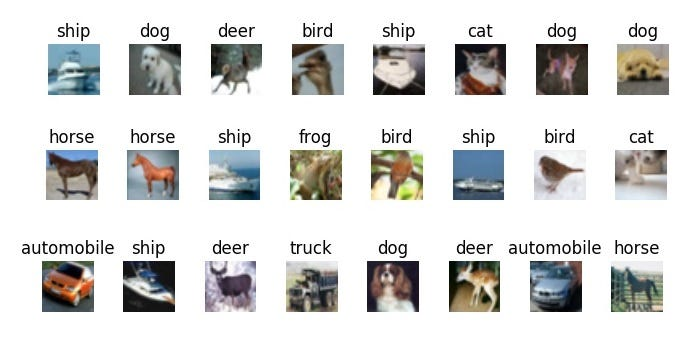

In [ ]:
import os
import math
import random
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

import umap
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import plotly.express as px

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE


device(type='cpu')

In [ ]:
# we set seeds to allow for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


In [ ]:
# Choose dataset: "cifar10" or "csv"
# CIFAR-10 can be swaped for another dataset (e.g., Fashion-MNIST).
DATASET_CHOICE = "cifar10"  # change to "csv" for your own data

# For CSV datasets
CSV_PATH = "your_dataset.csv"  # path to CSV (if using csv)
TARGET_COLUMN = "target"        # column name or integer index of label
TEST_SIZE = 0.2
VAL_SIZE = 0.1

# Training hyperparameters
BATCH_SIZE = 128
EPOCHS = 5            # increase for better accuracy; keep low for class demo speed
LR = 1e-3
WEIGHT_DECAY = 1e-4

# Embedding & viz settings
EMBED_BATCH_SIZE = 256
TSNE_PERPLEXITY = 30
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
N_PCA_COMPONENTS = 50
MAX_POINTS_VIZ = 5000   # subsample for fast t-SNE/UMAP plots


## 1.   Train an NN


These functions will load the data, split into train, val and test. Loaders are particular tool from pytorch that allows us to process observation efficiently in batches.

In [ ]:
from typing import Tuple

def load_cifar10(batch_size: int):
    import torchvision
    import torchvision.transforms as T

    transform = T.Compose([
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
    ])

    trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
    testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

    # Split train into train/val
    n_total = len(trainset)
    n_val = int(0.1 * n_total)
    n_train = n_total - n_val
    train_subset, val_subset = torch.utils.data.random_split(trainset, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    class_names = trainset.classes
    input_shape = (3, 32, 32)
    n_classes = 10
    return train_loader, val_loader, test_loader, class_names, input_shape, n_classes


def load_csv_dataset(path: str, target_column, batch_size: int):
    df = pd.read_csv(path)
    # target column can be name or int index
    if isinstance(target_column, int):
        y = df.iloc[:, target_column].values
        X = df.drop(df.columns[target_column], axis=1).values
    else:
        y = df[target_column].values
        X = df.drop(columns=[target_column]).values

    # Encode y if not numeric
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    y_enc = LabelEncoder().fit_transform(y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_enc, test_size=TEST_SIZE, random_state=SEED, stratify=y_enc)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

    def to_loader(X, y):
        tensX = torch.tensor(X, dtype=torch.float32)
        tensY = torch.tensor(y, dtype=torch.long)
        ds = TensorDataset(tensX, tensY)
        return DataLoader(ds, batch_size=batch_size, shuffle=True)

    train_loader = to_loader(X_train, y_train)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long)), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)), batch_size=batch_size, shuffle=False)

    n_features = X.shape[1]
    n_classes = len(np.unique(y_enc))
    class_names = [str(c) for c in np.unique(y)]
    input_shape = (n_features,)
    return train_loader, val_loader, test_loader, class_names, input_shape, n_classes


We will build a small CNN for CIFAR or a small MLP for tabuar data. More on CNNs on the next sessions/classes.

In [ ]:

class SmallCNN(nn.Module):
    def __init__(self, n_classes=10, embed_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((4,4))
        )
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128*4*4, embed_dim)
        self.fc_out = nn.Linear(embed_dim, n_classes)

    def forward(self, x, return_embedding=False):
        h = self.conv(x)
        h = self.flatten(h)
        z = self.fc1(h)
        z = F.relu(z)
        logits = self.fc_out(z)
        if return_embedding:
            return logits, z
        return logits


class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.2),
            nn.Linear(256, embed_dim), nn.ReLU(),
        )
        self.fc_out = nn.Linear(embed_dim, n_classes)

    def forward(self, x, return_embedding=False):
        z = self.net(x)
        logits = self.fc_out(z)
        if return_embedding:
            return logits, z
        return logits


Once the functions and classes are defined, we can load the data and display it.

In [ ]:
if DATASET_CHOICE.lower() == "cifar10":
    train_loader, val_loader, test_loader, class_names, input_shape, n_classes = load_cifar10(BATCH_SIZE)
    model = SmallCNN(n_classes=n_classes, embed_dim=128)
elif DATASET_CHOICE.lower() == "csv":
    assert os.path.exists(CSV_PATH), f"CSV file not found: {CSV_PATH}"
    train_loader, val_loader, test_loader, class_names, input_shape, n_classes = load_csv_dataset(CSV_PATH, TARGET_COLUMN, BATCH_SIZE)
    model = MLP(in_dim=input_shape[0], n_classes=n_classes, embed_dim=64)
else:
    raise ValueError("DATASET_CHOICE must be 'cifar10' or 'csv'")

model = model.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)


100%|██████████| 170M/170M [00:02<00:00, 74.0MB/s]


Once the data is in the loaders, we can visualize images from some batches

In [ ]:
import matplotlib.pyplot as plt

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Function to unnormalize and show an image
def imshow(img):
    # Unnormalize for visualization (CIFAR-10 specific values)
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# Show 4 images from the batch
fig, axes = plt.subplots(1, 4, figsize=(10, 2.5))
for i in range(4):
    plt.sca(axes[i])
    imshow(images[i])
    plt.title(class_names[labels[i]])
plt.suptitle('Sample CIFAR-10 Training Images')
plt.show()

We will now define functions to run the model.

In [ ]:
import time

def accuracy(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()


def run_epoch(loader, train: bool):
    model.train() if train else model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n = 0
    for batch in loader:
        if DATASET_CHOICE == "cifar10":
            x, y = batch
        else:
            x, y = batch
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        if train:
            optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        if train:
            loss.backward()
            optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy(logits, y) * bs
        n += bs
    return total_loss / n, total_acc / n

In [ ]:
for epoch in range(1, EPOCHS+1):
    start_time = time.time() # Start timer
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    end_time = time.time() # End timer
    epoch_time = end_time - start_time # Calculate duration
    print(f"Epoch {epoch:02d} | Train loss {train_loss:.4f}, acc {train_acc:.4f} | Val loss {val_loss:.4f}, acc {val_acc:.4f} | Time: {epoch_time:.2f}s")

In [ ]:
test_loss, test_acc = run_epoch(test_loader, train=False)
print(f"Test loss {test_loss:.4f} | Test acc {test_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning:

'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.



Test loss 0.8071 | Test acc 0.7186


Our small CNN has already a pretty good accuracy



##2.   Extract embeddings from the second to last neuron



We will extract the embeddings from the second to last neuron z (the layer right before the final classification output), and evaluate the quality of such embeddings.

In [ ]:
@torch.no_grad()
def get_embeddings(loader):
    model.eval()
    all_z = []
    all_y = []
    for x, y in DataLoader(loader.dataset, batch_size=EMBED_BATCH_SIZE, shuffle=False):
        x = x.to(DEVICE)
        logits, z = model(x, return_embedding=True)
        all_z.append(z.cpu().numpy())
        all_y.append(y.numpy())
    Z = np.concatenate(all_z, axis=0)
    Y = np.concatenate(all_y, axis=0)
    return Z, Y

Z_train, y_train = get_embeddings(train_loader)
Z_test, y_test = get_embeddings(test_loader)
print("Embeddings shapes:", Z_train.shape, Z_test.shape)


Embeddings shapes: (45000, 128) (10000, 128)




##3.   Visualizing embeddings



Because our brains cannot go further than 3D, we need to reduce the dimensionality of the embeddings using PCA, t-SNE or UMAP. To speed things up, we will not plot the feature space with all samples, but with a subset.

In [ ]:
# Subsample for speed (esp. t-SNE/UMAP)

def subsample(X, y, max_points=5000, seed=SEED):
    if len(X) <= max_points:
        return X, y
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=max_points, replace=False)
    return X[idx], y[idx]

X_vis, y_vis = subsample(Z_test, y_test, MAX_POINTS_VIZ)

# PCA 2 components
pca = PCA(n_components=2, random_state=SEED)
X_pca2 = pca.fit_transform(X_vis)
# PCA 3 components
pca3 = PCA(n_components=3, random_state=SEED)
X_pca3 = pca3.fit_transform(X_vis)

# t-SNE
X_tsne2 = TSNE(n_components=2, perplexity=TSNE_PERPLEXITY, random_state=SEED, init='pca', learning_rate='auto').fit_transform(X_vis)

# UMAP
um = umap.UMAP(n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST, n_components=2, random_state=SEED)
X_umap2 = um.fit_transform(X_vis)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Each color is one of the labels. Which dimensionality reduction displays them better in 2D?

In [ ]:
plt.figure(figsize=(16,4))
for i, (X2, title) in enumerate([(X_pca2, 'PCA (2D)'), (X_tsne2, 't-SNE (2D)'), (X_umap2, 'UMAP (2D)')]):
    plt.subplot(1,3,i+1)
    scatter = plt.scatter(X2[:,0], X2[:,1], c=y_vis, s=4, cmap='tab10', alpha=0.8)
    plt.title(title)
    plt.xticks([]); plt.yticks([])
plt.suptitle('Latent space projections of test embeddings')
plt.show()


In [ ]:
labels_vis = [class_names[c] for c in y_vis]  # map 0..9 -> names
fig = px.scatter_3d(
    x=X_pca3[:,0], y=X_pca3[:,1], z=X_pca3[:,2],
    color=labels_vis,
    title='PCA (3D) of test embeddings',
    opacity=0.7, height=600
)
fig.show()



## 4.   KNN and linear probs



We will compare classification accuracies on embeddings and on original data. This will tell us how well-structured and separable the learned features are. If a simple classifier like kNN or logistic regression can achieve high accuracy on these embeddings, it implies that the network has learned a very good, organized, and useful internal representation of the data

In [ ]:
import time
from collections import Counter

# kNN purity in embedding vs input space
k = 5

# Embedding space
knn_embed = KNeighborsClassifier(n_neighbors=k)
start_time_knn_emb = time.time() # Start timer

knn_embed.fit(Z_train, y_train)
acc_embed = knn_embed.score(Z_test, y_test)
end_time_knn_emb = time.time() # End timer

print(f"kNN (k={k}) accuracy in embedding space: {acc_embed:.3f}")
print(f"time needed to analyze embeddings {end_time_knn_emb-start_time_knn_emb:.2f}s")


start_time_knn_orig = time.time() # Start timer

# Input space baseline
if DATASET_CHOICE == 'cifar10':
    # Flatten inputs for a crude baseline
    def collect_raw(loader):
        Xs, ys = [], []
        for x,y in DataLoader(loader.dataset, batch_size=EMBED_BATCH_SIZE, shuffle=False):
            Xs.append(x.view(x.size(0), -1).numpy())
            ys.append(y.numpy())
        return np.concatenate(Xs), np.concatenate(ys)
    Xtr_raw, ytr_raw = collect_raw(train_loader)
    Xte_raw, yte_raw = collect_raw(test_loader)
else:
    # For CSV we already had standardized inputs; reuse
    # (reconstruct from loaders)
    def collect_raw_tab(loader):
        Xs, ys = [], []
        for x,y in DataLoader(loader.dataset, batch_size=EMBED_BATCH_SIZE, shuffle=False):
            Xs.append(x.numpy())
            ys.append(y.numpy())
        return np.concatenate(Xs), np.concatenate(ys)
    Xtr_raw, ytr_raw = collect_raw_tab(train_loader)
    Xte_raw, yte_raw = collect_raw_tab(test_loader)

knn_raw = KNeighborsClassifier(n_neighbors=k)
knn_raw.fit(Xtr_raw, ytr_raw)
acc_raw = knn_raw.score(Xte_raw, yte_raw)

end_time_knn_orig = time.time() # End timer
print(f"time needed to analyze original {end_time_knn_orig-start_time_knn_orig:.2f}s")

print(f"kNN (k={k}) accuracy in raw input space: {acc_raw:.3f}")

kNN (k=5) accuracy in embedding space: 0.719
time needed to analyze embeddings 4.72s
time needed to analyze original 95.50s
kNN (k=5) accuracy in raw input space: 0.334


We can also perform a logit classification. This takes too long for the input data. Better skip.

In [ ]:
probe = LogisticRegression(max_iter=1000, n_jobs=-1)
probe.fit(Z_train, y_train)
probe_acc = probe.score(Z_test, y_test)
print(f"Linear probe on embeddings (logistic regression) accuracy: {probe_acc:.3f}")

probe_raw = LogisticRegression(max_iter=1000, n_jobs=-1)
probe_raw.fit(Xtr_raw, ytr_raw)
probe_raw_acc = probe_raw.score(Xte_raw, yte_raw)
print(f"Linear probe on raw inputs accuracy: {probe_raw_acc:.3f}")


We will now look at a few images, to see what the model considers important.

In [ ]:
# Select the slice/image you want to view.
bach_slice = slice(1, 2)


if DATASET_CHOICE == 'cifar10':
    import torchvision
    import torchvision.transforms as T
    # collect one batch
    (x_batch, y_batch) = next(iter(test_loader))
    x_batch = x_batch.to(DEVICE)
    y_batch = y_batch.to(DEVICE)

    x = x_batch[bach_slice].clone().detach().requires_grad_(True)
    model.eval()
    logits = model(x)
    target = logits.argmax(dim=1)
    loss = logits[0, target]
    loss.backward()
    sal = x.grad.detach().abs().mean(dim=1).cpu().numpy()[0]  # (H,W)

    # Normalize saliency for display
    sal = (sal - sal.min()) / (sal.max() + 1e-8)
    img = x.detach().cpu().numpy()[0].transpose(1,2,0)
    # Unnormalize for visualization roughly (CIFAR stats)
    img = img * np.array([0.247,0.243,0.261]) + np.array([0.4914,0.4822,0.4465])
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Input image"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(sal, cmap='hot'); plt.title("Saliency"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(img, alpha=0.6); plt.imshow(sal, cmap='hot', alpha=0.4); plt.title("Overlay"); plt.axis('off')
    plt.suptitle("Vanilla gradient saliency (which pixels most affect the top logit)")
    plt.show()
else:
    print("Saliency demo is only for image data (CIFAR-10). Skipping.")

**Saliency** (heatmap): shows importance per pixel, in 2D:

Bright yellow / red = high influence
Dark = low influence

For a cat, saliency often highlights the face, ears, or outline.
For a car, saliency lights up wheels and body edges.
For a frog, the silhouette and eyes.

**Overlay**: original image plus where the model concentrates its attention. It is easier to interpret.



##5.   Interpolation



Now, buckleup buckaroos, because the following takes some mental effort. We will interpolate in embedding space between to observations of different classes: 0 plane and 1 automobile.

The plot shows the predicted probability for each of the 10 possible classes at every step along that path between the two observations.

So, as we 'travel' in the latent space from sample_A (say, an 'airplane') to sample_B (say, a 'car'), the plot tracks how the model's confidence for 'airplane', 'cat', 'dog', 'truck', etc., changes. You'll typically see the probability of the initial class (yA) decreasing, the probability of the final class (yB) increasing, and potentially other class probabilities briefly rising or falling in between, showing the model's uncertainty or decision boundaries.

In [ ]:

# Interpolate in embedding space between two test samples and track class probabilities
@torch.no_grad()
def get_single_embedding(x):
    model.eval()
    logits, z = model(x.to(DEVICE), return_embedding=True)
    return z.cpu(), torch.softmax(logits, dim=1).cpu()

# pick two examples of different classes
idx_a = 0
idx_b = 1

# Collect two test samples from dataset
(xA, yA) = test_loader.dataset[idx_a]
(xB, yB) = test_loader.dataset[idx_b]

if DATASET_CHOICE == 'cifar10':
    xA_t = xA.unsqueeze(0)
    xB_t = xB.unsqueeze(0)
else:
    xA_t = xA.unsqueeze(0)
    xB_t = xB.unsqueeze(0)

zA, pA = get_single_embedding(xA_t)
zB, pB = get_single_embedding(xB_t)

# Linear interpolation
alphas = np.linspace(0, 1, 21)
probs = []
for a in alphas:
    z = (1-a)*zA + a*zB
    # Pass through final layer only
    logits = model.fc_out(z.to(torch.float32).to(DEVICE))
    prob = torch.softmax(logits, dim=1).cpu().detach().numpy()[0] # Added .detach() here
    probs.append(prob)
probs = np.stack(probs)

plt.figure(figsize=(8,4))
for c in range(len(class_names)):
    plt.plot(alphas, probs[:, c], label=str(class_names[c]), alpha=0.6)
plt.xlabel('Interpolation α (0=a, 1=b)')
plt.ylabel('Class probability')
plt.title('Class probabilities along latent interpolation')
plt.legend(ncol=5, fontsize=8)
plt.show()


**Bottomline**:

Latent space plots show global class structure
Saliency maps show local decision rationale

OR

“How does the network separate classes globally?”
and
“What cues does it use on individual examples?”


## What happened?
If you feel confused like John Travolta's meme, here you have a short summary.

1.- First we simply **trained** a CNN.

2- **Latent embeddings**: We grab how the CNN "mapped" the data from the **penultimate layer**. These vectors are the network's internal representation right before classification.

3- **Visualization** If the network learned useful structure, embeddings for the same class will cluster; different classes will separate. EAch dimensionality reduction is useful in its own way.
  - **PCA** preserves **global linear** structure; fast and stable.
  - **t-SNE** emphasizes **local neighborhoods**, often yielding well-separated clusters (but distances between clusters are not globally meaningful).
  - **UMAP** balances local/global structure and is often faster than t-SNE.

4- **kNN & linear probes**: If a simple model (kNN or logistic regression) performs well on the embeddings, it suggests the representation is **linearly separable** and well-structured.

5- **Interpolation**: By interpolating between two embeddings, we can see how the classifier's beliefs shift along a path through latent space—revealing **decision boundary** geometry.



## Questions to cement your understanding
- Do clusters align with classes? Which classes overlap? Why?
- How do PCA vs t-SNE vs UMAP differ in the same data?
- Does a linear probe on embeddings beat one on raw inputs? What does that imply?
- What happens to kNN accuracy in latent vs raw space? Why?
- Where does the model seem uncertain (low margins) and how does that appear in the latent map?

## Tips
- Increase **EPOCHS** for better accuracy if time allows.
- For very large datasets, reduce **MAX_POINTS_VIZ** or use just **PCA** in class.
- Swap CIFAR-10 for another dataset (e.g., Fashion-MNIST) by adjusting the loader.
- For tabular CSVs, ensure the target column is set in `TARGET_COLUMN` and check class balance.
